In [1]:
import numpy as np
import networkx as nx
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.metrics import normalized_mutual_info_score
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from node2vec import Node2Vec

# Spectral Sparsification

In [2]:
def spectral_sparsify(G, T):
    ### Calculate effective resistance
    n = len(G.nodes())
    m = len(G.edges())
    E = np.zeros((m, n))
    edge_idx = 0
    edges = list(G.edges())
    for edge in edges:
        E[edge_idx, edge[0]] = 1
        E[edge_idx, edge[1]] = -1
        edge_idx += 1
    
    L = E.T@E
    L_pinv = np.linalg.pinv(L)

    R = np.diagonal(E@L_pinv@E.T)
    probs = R/R.sum()

    ### Sample edges
    sampled_edge_counts = np.random.multinomial(T, probs)
    G_sparse = nx.Graph()
    G_sparse.add_nodes_from(G.nodes())
    for i in range(len(sampled_edge_counts)):
        u, v = edges[i]
        if sampled_edge_counts[i] == 0:
            continue
        else:
            G_sparse.add_edge(u, v, weight=sampled_edge_counts[i]/(T*probs[i]))

    return G_sparse

In [65]:
G = nx.from_numpy_array(A)
print(len(G.nodes()))
G_sparse = spectral_sparsify(G, np.sum(A)/10)
print(len(G_sparse.nodes()))
A_sparse = nx.adjacency_matrix(G_sparse, weight='weight').toarray()
spectral_clustering = SpectralClustering(n_clusters=3, affinity='precomputed', random_state=seed)
cluster_labels = spectral_clustering.fit_predict(A_sparse)
nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
print(nmi_score)
print(np.sum(A_sparse>0)/2)

300


300
0.9249874689891361
876.0


In [66]:
spectral_clustering = SpectralClustering(n_clusters=3, affinity='precomputed', random_state=seed)
cluster_labels = spectral_clustering.fit_predict(A)
nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
print(nmi_score)
print(np.sum(A)/2)

1.0
4813.0


# DP Algorithms

In [3]:
def edge_flip(A, epsilon):
    """
    Definition 5 from: https://arxiv.org/pdf/2105.12615
    """
    A_perturbed = np.zeros(A.shape)
    for i in range(A.shape[0]):
        for j in range(i+1, A.shape[0]):
            x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon)))
            if x == 1:
                A_perturbed[i,j] = 1 - A[i,j]
                A_perturbed[j,i] = 1 - A[i,j]
            else:
                A_perturbed[i,j] = A[i,j]
                A_perturbed[j,i] = A[i,j]
    
    return A_perturbed

In [4]:
def edge_flip_sparsified(A, epsilon):
    """
    Definition 5 from: https://arxiv.org/pdf/2105.12615
    + 
    Spectral Sparsification
    """

    ### Distribute privacy budget
    epsilon_1 = 0.01*epsilon
    epsilon_2 = epsilon - epsilon_1

    ### Calculate private total edge
    n = A.shape[0]
    total_possible_edges = (n**2 - n)/2
    T = int(np.clip(np.sum(A)/2 + np.random.laplace(scale=1/epsilon_1), 0, total_possible_edges))

    ### Edge Flip
    A_perturbed = np.zeros(A.shape)
    for i in range(A.shape[0]):
        for j in range(i+1, A.shape[0]):
            x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon_2)))
            if x == 1:
                A_perturbed[i,j] = 1 - A[i,j]
                A_perturbed[j,i] = 1 - A[i,j]
            else:
                A_perturbed[i,j] = A[i,j]
                A_perturbed[j,i] = A[i,j]
    

    ### Spectral sparsification
    G_perturbed = nx.from_numpy_array(A_perturbed)
    G_perturbed_sparsed = spectral_sparsify(G_perturbed, T)
    A_perturbed_sparsed = nx.adjacency_matrix(G_perturbed_sparsed, weight='weight')

    return A_perturbed_sparsed.toarray(), T

In [5]:
def edge_flip_sparsified_test(A, epsilon, T=None, n_edge=None):
    """
    Definition 5 from: https://arxiv.org/pdf/2105.12615
    + 
    Spectral Sparsification
    """

    ### Distribute privacy budget
    epsilon_1 = 0.01*epsilon
    epsilon_2 = epsilon - epsilon_1

    ### Calculate private total edge
    n = A.shape[0]
    total_possible_edges = (n**2 - n)/2
    # T = int(np.clip(np.sum(A)/2 + np.random.laplace(scale=1/epsilon_1), 0, total_possible_edges))

    ### Edge Flip
    A_perturbed = np.zeros(A.shape)
    for i in range(A.shape[0]):
        for j in range(i+1, A.shape[0]):
            x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon_2)))
            if x == 1:
                A_perturbed[i,j] = 1 - A[i,j]
                A_perturbed[j,i] = 1 - A[i,j]
            else:
                A_perturbed[i,j] = A[i,j]
                A_perturbed[j,i] = A[i,j]
    

    ### Spectral sparsification
    G_perturbed = nx.from_numpy_array(A_perturbed)
    if T is not None:
        G_perturbed_sparsed = spectral_sparsify(G_perturbed, T=T)
    else:
        G_perturbed_sparsed = spectral_sparsify(G_perturbed, n_edge=n_edge)
    A_perturbed_sparsed = nx.adjacency_matrix(G_perturbed_sparsed, weight='weight')

    return A_perturbed_sparsed.toarray()

In [6]:
def lapgraph(A, epsilon):
    """
    Algorithm 4 from: https://arxiv.org/pdf/2108.06504
    """

    # Distribute privacy budget to 2 steps: 
    # + Adding Laplace noise to the A matrix
    # + Keeping the top cells within the perturbed matrix

    epsilon_1 = 0.01*epsilon
    epsilon_2 = epsilon - epsilon_1

    # Get DP edge count
    T = int(np.sum(A)/2 + np.random.laplace(scale=1/epsilon_1)) # Laplace noise may not be suitable for count statistics

    # Get A_perturbed with Laplace noise
    A_perturbed = np.zeros(A.shape)
    for i in range(A.shape[0]):
        for j in range(i+1, A.shape[0]):
            A_perturbed[i,j] = A[i,j] + np.random.laplace(scale=1/epsilon_2)

    mask = np.tril(np.ones(A.shape), k=0) * -10**10
    A_perturbed = A_perturbed + mask

    # Get the indices of the top T cells
    top_indices = np.unravel_index(np.argpartition(A_perturbed.flatten(), -T)[-T:], A.shape)

    # Reset all cells to 0 and set only cells in top_indices to 1
    A_perturbed = np.zeros(A.shape)
    A_perturbed[top_indices] = 1
    
    return A_perturbed + A_perturbed.T

# Embedding Algorithms

In [7]:
def deepwalk_get_embeddings(G, k, seed=0, window=5):
    node2vec = Node2Vec(G, dimensions=k, walk_length=100, num_walks=10, workers=1, seed=seed, quiet=True)
    model = node2vec.fit(window=window, min_count=0, seed=seed, sg=1, negative=5, epochs=1, ns_exponent=1)

    emb_X = []
    for node_name in G.nodes():
        emb_X.append(model.wv[str(node_name)])
    H = np.vstack(emb_X)
    H = H / np.linalg.norm(H, ord=2, axis=1, keepdims=True)

    return H

# Degree-corrected SBM

In [10]:
def degree_corrected_sbm(sizes, probs, a, seed=None):
    """
    Generate a degree-corrected stochastic block model (DCSBM) graph.
    Edges are sampled from Bernoulli distributions.

    Args:
        sizes: list of ints, sizes of each block.
        probs: 2D array-like, base connection probabilities between blocks.
        a:
        seed: int, random seed.

    Returns:
        G: networkx.Graph, the generated DCSBM graph.
        labels: list, block label for each node.
    """

    if seed is not None:
        np.random.seed(seed)

    n = sum(sizes)

    # Assign block labels
    labels = []
    for k, sz in enumerate(sizes):
        labels += [k] * sz
    labels = np.array(labels)

    # Degree parameters
    theta = []
    idx = 0
    for group_size in sizes:
        for i in range(idx, idx+group_size):
            z = np.random.normal(0, 0.25)
            q = np.abs(z) + 1 - (2*np.pi)**(-1/2)
            theta.append(q)

            # if i == idx:
            #     theta.append(1)
            # else:
            #     theta.append(np.random.uniform(a, 1))
        idx += group_size
    print(f"Theta: {theta}")

    # Build probability matrix for all pairs
    P = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            k = labels[i]
            l = labels[j]
            pij = theta[i] * theta[j] * probs[k][l]
            pij = min(max(pij, 0), 1)  # Clamp to [0,1]
            P[i, j] = pij
            P[j, i] = pij

    # Sample adjacency matrix
    A = np.triu(np.random.binomial(1, P), 1)
    A = A + A.T

    G = nx.from_numpy_array(A)
    return G, labels


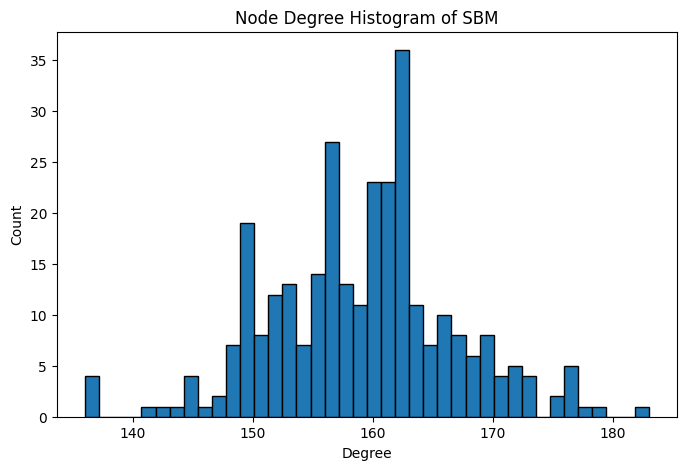

In [10]:
G_sbm = nx.stochastic_block_model(sizes, probs, seed=10)
degrees = [d for n, d in G_sbm.degree()]
plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=40, edgecolor='black')
plt.title("Node Degree Histogram of SBM")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.show()


Theta: [0.6325966235673666, 0.6321344514816514, 0.7379905126426423, 0.7017411876773236, 0.7370350407713251, 0.8106032406115944, 0.8004110326972234, 1.0437238714731065, 0.9470314144084993, 1.0569674378322174, 1.0786787676115133, 1.3886906544520254, 0.6337341147850826, 0.6342641567890461, 0.7302246975264655, 0.6783305275797455, 0.7134260822731009, 0.808368173875754, 0.8511473847162643, 1.0221891901644973, 0.6693355598245718, 1.0339450870273945, 0.6264053350521268, 0.9058000338160876, 1.008045865570594, 0.8354616122761509, 0.797004593211291, 0.7998078485300397, 0.6873668803432116, 0.6412467281406671, 1.028596294570381, 0.8307035260983078, 0.7891399916370174, 0.6163491126065583, 0.8222662685292006, 0.9765739282804, 0.8006004089380847, 0.8366661720524942, 0.9260778110556787, 0.8427389500204647, 0.9309548960215908, 0.7692790937644622, 0.6601232372513097, 0.6749951643729, 0.6256636259817441, 0.7976615665388436, 1.0227056540004835, 0.6512058412165389, 0.850521005738331, 0.6108093116904956, 1.0

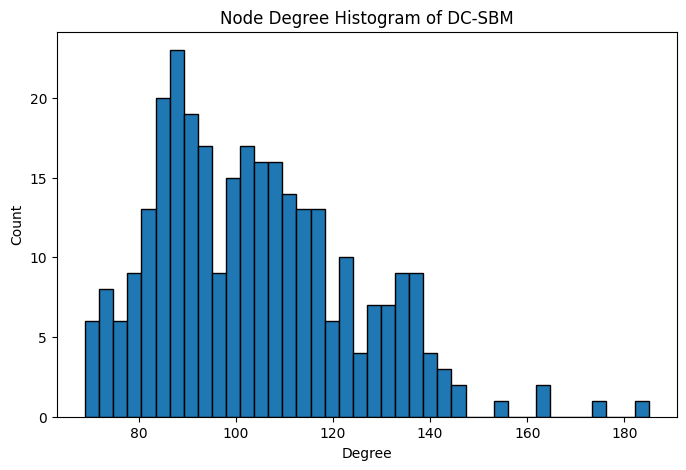

In [13]:
G_tt, labels_tt = degree_corrected_sbm([100, 100, 100], probs, a = 0.3, seed=None)
degrees = [d for n, d in G_tt.degree()]
plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=40, edgecolor='black')
plt.title("Node Degree Histogram of DC-SBM")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.show()


# Experiments

## Dense SBM

In [50]:
sizes = [100, 100, 100]
p = 0.8
r = 0.4
deepwalk_dimension=32
n_clusters = 3
sample_size = 10

n = np.sum(sizes)
total_edges = (n**2 - n)/2

probs = [
    [p, r, r],
    [r, p, r],
    [r, r, p],
]

# Define epsilon values to test
epsilon_values = np.logspace(-1, 1, num=12) 

# Initialize results storage
results = {
    'Spectral Clustering - no Privacy': [[] for _ in range(len(epsilon_values))],
    'LapGraph + Normalized Laplacian Eigenvector + KMeans': [[] for _ in range(len(epsilon_values))],
    'Edge Flip + Normalized Laplacian Eigenvector + KMeans': [[] for _ in range(len(epsilon_values))],
    'LapGraph + DeepWalk + KMeans': [[] for _ in range(len(epsilon_values))],
    'Edge Flip + DeepWalk + Kmeans': [[] for _ in range(len(epsilon_values))],
    'Edge Flip + Sparse + Normalized Laplacian Eigenvector + KMeans': [[] for _ in range(len(epsilon_values))],
    'Edge Flip + Sparse + DeepWalk + Kmeans': [[] for _ in range(len(epsilon_values))],
}

edge_density = {
    'LapGraph': [[] for _ in range(len(epsilon_values))],
    'Edge Flip': [[] for _ in range(len(epsilon_values))],
    'Edge Flip + Sparse': [[] for _ in range(len(epsilon_values))]
}

# Test each epsilon value
for idx, epsilon in enumerate(epsilon_values):
    print(f"Testing epsilon = {epsilon}")

    for run in range(sample_size):
        seed = run
        np.random.seed(seed)

        #### Generate the SBM graph
        G = nx.stochastic_block_model(sizes, probs, seed=seed)
        A = nx.to_numpy_array(G)

        # Get the true labels from the SBM
        true_labels = []
        for i, size in enumerate(sizes):
            true_labels.extend([i] * size)


        #### Evaluate

        # Original matrix (no perturbation)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        cluster_labels = spectral_clustering.fit_predict(A)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Spectral Clustering - no Privacy'][idx].append(nmi_score)

        # LapGraph + Normalized Laplacian Eigenvector + KMeans
        A_lg = lapgraph(A, epsilon)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        cluster_labels = spectral_clustering.fit_predict(A_lg)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['LapGraph + Normalized Laplacian Eigenvector + KMeans'][idx].append(nmi_score)
        edge_density['LapGraph'][idx].append((np.sum(A_lg>0)/2)/total_edges)
        
        # Edge Flip + Normalized Laplacian Eigenvector + KMeans 
        A_ef = edge_flip(A, epsilon)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        cluster_labels = spectral_clustering.fit_predict(A_ef)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Edge Flip + Normalized Laplacian Eigenvector + KMeans'][idx].append(nmi_score)
        edge_density['Edge Flip'][idx].append((np.sum(A_ef>0)/2)/total_edges)

        # LapGraph + DeepWalk + KMeans
        G_test = nx.from_numpy_array(A_lg)
        X = deepwalk_get_embeddings(G_test, deepwalk_dimension, seed=seed)
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=seed)
        cluster_labels = kmeans.fit_predict(X)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['LapGraph + DeepWalk + KMeans'][idx].append(nmi_score)

        # Edge Flip + DeepWalk + Kmeans
        G_test = nx.from_numpy_array(A_ef)
        X = deepwalk_get_embeddings(G_test, deepwalk_dimension, seed=seed)
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=seed)
        cluster_labels = kmeans.fit_predict(X)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Edge Flip + DeepWalk + Kmeans'][idx].append(nmi_score)

        # Edge Flip + Sparse + Normalized Laplacian Eigenvector + KMeans 
        A_ef_sparse = edge_flip_sparsified(A, epsilon)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        cluster_labels = spectral_clustering.fit_predict(A_ef_sparse)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Edge Flip + Sparse + Normalized Laplacian Eigenvector + KMeans'][idx].append(nmi_score)
        edge_density['Edge Flip + Sparse'][idx].append((np.sum(A_ef_sparse>0)/2)/total_edges)

        # Edge Flip + Sparse + DeepWalk + Kmeans
        G_test = nx.from_numpy_array(A_ef_sparse)
        X = deepwalk_get_embeddings(G_test, deepwalk_dimension, seed=seed)
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=seed)
        cluster_labels = kmeans.fit_predict(X)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Edge Flip + Sparse + DeepWalk + Kmeans'][idx].append(nmi_score)


Testing epsilon = 0.1
Testing epsilon = 0.1519911082952934
Testing epsilon = 0.23101297000831597
Testing epsilon = 0.3511191734215131
Testing epsilon = 0.533669923120631
Testing epsilon = 0.8111308307896873
Testing epsilon = 1.232846739442066
Testing epsilon = 1.8738174228603839
Testing epsilon = 2.848035868435802
Testing epsilon = 4.328761281083059
Testing epsilon = 6.5793322465756825
Testing epsilon = 10.0


In [55]:
#save output
import os
import json


def convert_to_json_serializable(obj):
    # Recursively convert numpy types to native Python types
    if isinstance(obj, dict):
        return {k: convert_to_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_json_serializable(v) for v in obj]
    elif hasattr(obj, "tolist"):
        return obj.tolist()
    elif obj is None:
        return None
    else:
        return obj

os.makedirs("logs", exist_ok=True)
with open("logs/ours/dense_sbm_with_spectral_sparse.json", "w") as f:
    json.dump(convert_to_json_serializable(results), f)


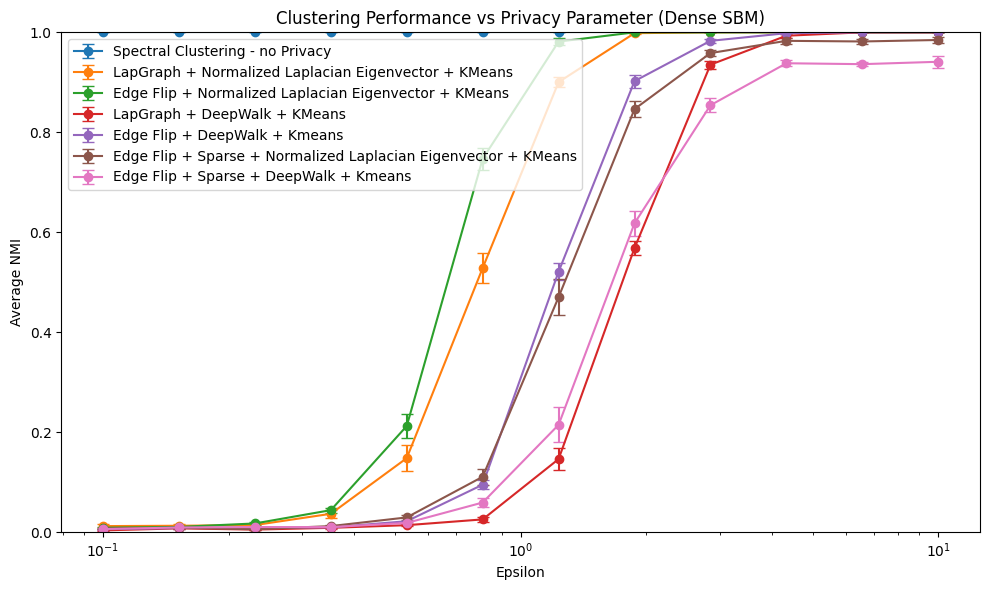

In [53]:
### Plotting

# Compute mean and std for each method at each epsilon
method_means = {}
method_stds = {}
for method in results:
    means = []
    stds = []
    for j, eps in enumerate(epsilon_values):
        nmi_scores = [v for v in results[method][j] if v is not None]
        if len(nmi_scores) > 0:
            means.append(np.mean(nmi_scores))
            stds.append(np.std(nmi_scores, ddof=1)/np.sqrt(sample_size))
        else:
            means.append(np.nan)
            stds.append(np.nan)
    method_means[method] = means
    method_stds[method] = stds

# Plot
plt.figure(figsize=(10, 6))
for i, method in enumerate(results.keys()):
    means = method_means[method]
    stds = method_stds[method]
    plt.errorbar(
        [float(e) for e in epsilon_values], 
        means, 
        yerr=stds, 
        label=method, 
        marker='o', 
        capsize=4, 
        linestyle='-'
    )

plt.xscale('log')
plt.ylim(0,1)
plt.xlabel('Epsilon')
plt.ylabel('Average NMI')
plt.title('Clustering Performance vs Privacy Parameter (Dense SBM)')
plt.legend()
plt.tight_layout()
plt.show()

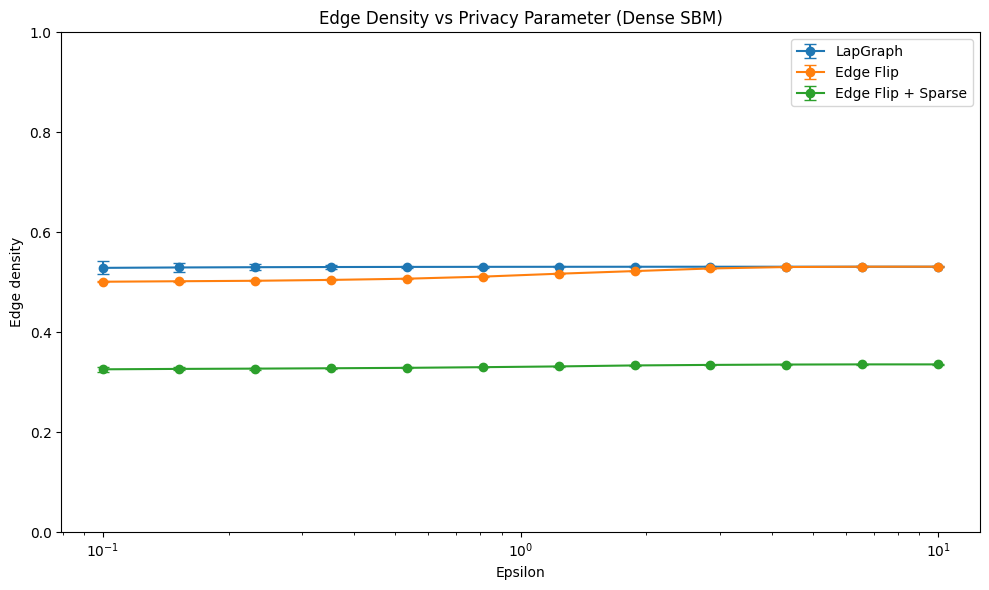

In [54]:
### Plotting edge density

# Compute mean and std for each method at each epsilon
method_means = {}
method_stds = {}
for method in edge_density:
    means = []
    stds = []
    for j, eps in enumerate(epsilon_values):
        density_scores = [v for v in edge_density[method][j] if v is not None]
        if len(density_scores) > 0:
            means.append(np.mean(density_scores))
            stds.append(np.std(density_scores, ddof=1)/np.sqrt(sample_size))
        else:
            means.append(np.nan)
            stds.append(np.nan)
    method_means[method] = means
    method_stds[method] = stds

# Plot
plt.figure(figsize=(10, 6))
for i, method in enumerate(edge_density.keys()):
    means = method_means[method]
    stds = method_stds[method]
    plt.errorbar(
        [float(e) for e in epsilon_values], 
        means, 
        yerr=stds, 
        label=method, 
        marker='o', 
        capsize=4, 
        linestyle='-'
    )

plt.xscale('log')
plt.ylim(0,1)
plt.xlabel('Epsilon')
plt.ylabel('Edge density')
plt.title('Edge Density vs Privacy Parameter (Dense SBM)')
plt.legend()
plt.tight_layout()
plt.show()

## Sparse SBM

In [107]:
# sizes = [100, 100, 100]
np.random.seed(0)
block_size = 100
num_blocks = 3
sizes = [block_size] * num_blocks

n = np.sum(sizes)
total_edges = (n**2 - n)/2
p = 1.5*n**(-0.3)
r = 0.15*n**(-0.3)
print(f"Intra prob: {p}")
print(f"Inter prob: {r}")
deepwalk_dimension=32
n_clusters = 3
sample_size = 10


probs = np.eye(num_blocks) * p + (1 - np.eye(num_blocks)) * r

# Define epsilon values to test
epsilon_values = np.logspace(-0.5, 0.5, num=12) 

# Initialize results storage
results = {
    # 'Spectral Clustering - no Privacy': [[] for _ in range(len(epsilon_values))],
    'LapGraph + Normalized Laplacian Eigenvector + KMeans': [[] for _ in range(len(epsilon_values))],
    'Edge Flip + Normalized Laplacian Eigenvector + KMeans': [[] for _ in range(len(epsilon_values))],

    'Edge Flip + Adjusted + Eigenvector + KMeans': [[] for _ in range(len(epsilon_values))],
    'Edge Flip + Adjusted + Clipped + Normalized Laplacian Eigenvector + KMeans': [[] for _ in range(len(epsilon_values))],

    # 'LapGraph + DeepWalk + KMeans': [[] for _ in range(len(epsilon_values))],
    # 'Edge Flip + DeepWalk + Kmeans': [[] for _ in range(len(epsilon_values))],
    # 'Edge Flip + Sparse + Normalized Laplacian Eigenvector + KMeans': [[] for _ in range(len(epsilon_values))],
    # 'Edge Flip + Shifted + Sparse + Normalized Laplacian Eigenvector + KMeans': [[] for _ in range(len(epsilon_values))],
    # 'Edge Flip + Sparse + DeepWalk + Kmeans': [[] for _ in range(len(epsilon_values))],
}

# edge_density = {
#     'LapGraph': [[] for _ in range(len(epsilon_values))],
#     'Edge Flip': [[] for _ in range(len(epsilon_values))],
#     'Edge Flip + Sparse': [[] for _ in range(len(epsilon_values))],
# }

# Test each epsilon value
for idx, epsilon in enumerate(epsilon_values):
    print(f"Testing epsilon = {epsilon}")

    for run in range(sample_size):
        seed = run
        np.random.seed(seed)

        #### Generate the SBM graph
        G = nx.stochastic_block_model(sizes, probs, seed=seed)
        A = nx.to_numpy_array(G)

        # Get the true labels from the SBM
        true_labels = []
        for i, size in enumerate(sizes):
            true_labels.extend([i] * size)


        #### Evaluate

        # # Original matrix (no perturbation)
        # spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        # cluster_labels = spectral_clustering.fit_predict(A)
        # nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        # results['Spectral Clustering - no Privacy'][idx].append(nmi_score)

        # LapGraph + Normalized Laplacian Eigenvector + KMeans
        A_lg = lapgraph(A, epsilon)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        cluster_labels = spectral_clustering.fit_predict(A_lg)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['LapGraph + Normalized Laplacian Eigenvector + KMeans'][idx].append(nmi_score)
        # edge_density['LapGraph'][idx].append((np.sum(A_lg>0)/2)/total_edges)
        
        # Edge Flip + Normalized Laplacian Eigenvector + KMeans 
        A_ef = edge_flip(A, epsilon)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        cluster_labels = spectral_clustering.fit_predict(A_ef)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Edge Flip + Normalized Laplacian Eigenvector + KMeans'][idx].append(nmi_score)
        # edge_density['Edge Flip'][idx].append((np.sum(A_ef>0)/2)/total_edges)


        # Edge Flip + Adjusted + Eigenvector + KMeans 
        A_ef_adjusted = A_ef/(np.exp(epsilon) - 1)/(np.exp(epsilon) + 1) - (1/(np.exp(epsilon) - 1)*(np.ones(n,n) - np.eye(n)))
        eigvals, eigvecs = np.linalg.eigh(A_ef_adjusted)
        topk_indices = np.argsort(np.abs(eigvals))[::-1][:n_clusters]
        eigvecs = eigvecs[:, topk_indices]
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=seed)
        cluster_labels = kmeans.fit_predict(eigvecs)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Edge Flip + Adjusted + Eigenvector + KMeans'][idx].append(nmi_score)


        # Edge Flip + Adjusted + Clipped + Normalized Laplacian Eigenvector + KMeans 
        A_ef_adjusted_clipped = A_ef_adjusted + 12321321 #- np.min(A_ef_adjusted)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        cluster_labels = spectral_clustering.fit_predict(A_ef_adjusted_clipped)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Edge Flip + Adjusted + Clipped + Normalized Laplacian Eigenvector + KMeans'][idx].append(nmi_score)



        # # Edge Flip + Sparse + Normalized Laplacian Eigenvector + KMeans 
        # A_ef_sparse = edge_flip_sparsified(A, epsilon)
        # spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        # cluster_labels = spectral_clustering.fit_predict(A_ef_sparse)
        # nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        # results['Edge Flip + Sparse + Normalized Laplacian Eigenvector + KMeans'][idx].append(nmi_score)
        # edge_density['Edge Flip + Sparse'][idx].append((np.sum(A_ef_sparse>0)/2)/total_edges)

        # # Edge Flip + Sparse + Normalized Laplacian Eigenvector + KMeans 
        # A_ef_sparse_shifted = A_ef_sparse - (1/(np.exp(epsilon) + 1)*(np.ones(n,n) - np.eye(n)))
        # spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        # # Clustering
        # # degrees = np.sum(A_ef_sparse_shifted, axis=1)
        # # D_inv_sqrt = np.diag(1.0 / np.sqrt(degrees + 1e-10))
        # # L = np.eye(n) - D_inv_sqrt @ A_ef_sparse_shifted @ D_inv_sqrt
        # eigvals, eigvecs = np.linalg.eigh(A_ef_sparse_shifted)
        # # Pick the top k columns in eigvecs, ordered by the absolute value of eigvals
        # k = n_clusters
        # topk_indices = np.argsort(np.abs(eigvals))[::-1][:k]
        # eigvecs = eigvecs[:, topk_indices]
        # kmeans = KMeans(n_clusters=3, n_init=10, random_state=seed)
        # cluster_labels = kmeans.fit_predict(eigvecs)
        # # Evaluate
        # nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        # results['Edge Flip + Shifted + Sparse + Normalized Laplacian Eigenvector + KMeans'][idx].append(nmi_score)

Intra prob: 0.2709910094026613
Inter prob: 0.02709910094026613
Testing epsilon = 0.31622776601683794
Testing epsilon = 0.3898603702549073
Testing epsilon = 0.48063808630643906
Testing epsilon = 0.5925530975545678
Testing epsilon = 0.7305271542664454
Testing epsilon = 0.9006280202112786
Testing epsilon = 1.1103363181676378
Testing epsilon = 1.368874509537081
Testing epsilon = 1.6876124757881479
Testing epsilon = 2.080567538217171
Testing epsilon = 2.5650209056800457
Testing epsilon = 3.1622776601683795


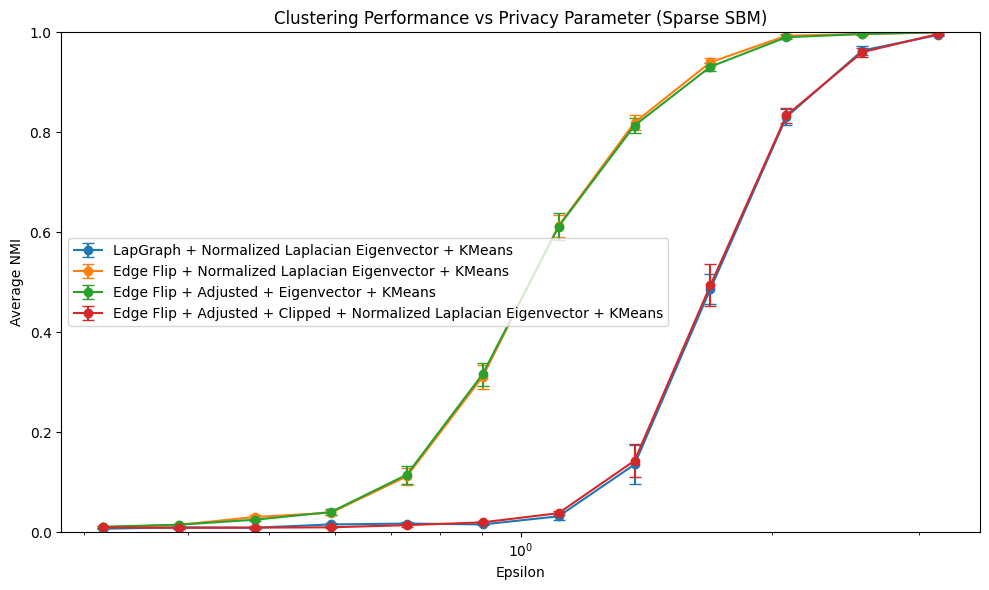

In [ ]:
### Plotting NMI

# Compute mean and std for each method at each epsilon
method_means = {}
method_stds = {}
for method in results:
    means = []
    stds = []
    for j, eps in enumerate(epsilon_values):
        nmi_scores = [v for v in results[method][j] if v is not None]
        if len(nmi_scores) > 0:
            means.append(np.mean(nmi_scores))
            stds.append(np.std(nmi_scores, ddof=1)/np.sqrt(sample_size))
        else:
            means.append(np.nan)
            stds.append(np.nan)
    method_means[method] = means
    method_stds[method] = stds

# Plot
plt.figure(figsize=(10, 6))
for i, method in enumerate(results.keys()):
    means = method_means[method]
    stds = method_stds[method]
    plt.errorbar(
        [float(e) for e in epsilon_values], 
        means, 
        yerr=stds, 
        label=method, 
        marker='o', 
        capsize=4, 
        linestyle='-'
    )

plt.xscale('log')
plt.ylim(0,1)
plt.xlabel('Epsilon')
plt.ylabel('Average NMI')
plt.title('Clustering Performance vs Privacy Parameter (Sparse SBM)')
plt.legend()
plt.tight_layout()
plt.show()

In [75]:
np.clip(np.array([[1,2],[3,1]]), a_min=2, a_max=None)

array([[2, 2],
       [3, 2]])

In [26]:
# sizes = [100, 100, 100]
np.random.seed(0)
block_size = 100
num_blocks = 3
sizes = [block_size] * num_blocks

n = np.sum(sizes)
total_edges = (n**2 - n)/2
p = 1.5*n**(-0.3)
r = 0.15*n**(-0.3)
print(f"Intra prob: {p}")
print(f"Inter prob: {r}")
deepwalk_dimension=32
n_clusters = 3
sample_size = 10


probs = np.eye(num_blocks) * p + (1 - np.eye(num_blocks)) * r

# Define epsilon values to test
epsilon_values = np.logspace(-0.5, 0.5, num=12) 

# Initialize results storage
results = {
    # 'LapGraph + Eigenvector + KMeans': [[] for _ in range(len(epsilon_values))],
    'Edge Flip + Eigenvector + KMeans': [[] for _ in range(len(epsilon_values))],
    'Edge Flip + Adjusted + Eigenvector + KMeans': [[] for _ in range(len(epsilon_values))],
    'Edge Flip + MSE Adjusted 1 + Eigenvector + KMeans': [[] for _ in range(len(epsilon_values))],
    'Edge Flip + Adjusted2 + Eigenvector + KMeans': [[] for _ in range(len(epsilon_values))]
    # 'Edge Flip + MSE Adjusted 2 + Eigenvector + KMeans': [[] for _ in range(len(epsilon_values))] 
    # 'Edge Flip + Sparse + Eigenvector + KMeans': [[] for _ in range(len(epsilon_values))],
    # 'Edge Flip + Adjusted + Sparse + Eigenvector + KMeans': [[] for _ in range(len(epsilon_values))],
}

edge_density = {
    'LapGraph': [[] for _ in range(len(epsilon_values))],
    'Edge Flip': [[] for _ in range(len(epsilon_values))],
    'Edge Flip + Sparse': [[] for _ in range(len(epsilon_values))],
}

# Test each epsilon value
for idx, epsilon in enumerate(epsilon_values):
    print(f"Testing epsilon = {epsilon}")

    for run in range(sample_size):
        seed = run
        np.random.seed(seed)

        #### Generate the SBM graph
        G = nx.stochastic_block_model(sizes, probs, seed=seed)
        A = nx.to_numpy_array(G)

        # Get the true labels from the SBM
        true_labels = []
        for i, size in enumerate(sizes):
            true_labels.extend([i] * size)


        #### Evaluate

        # # LapGraph + Eigenvector + KMeans
        # A_lg = lapgraph(A, epsilon)
        # eigvals, eigvecs = np.linalg.eigh(A_lg)
        # topk_indices = np.argsort(np.abs(eigvals))[::-1][:n_clusters]
        # eigvecs = eigvecs[:, topk_indices]
        # kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=seed)
        # cluster_labels = kmeans.fit_predict(eigvecs)
        # nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        # results['LapGraph + Eigenvector + KMeans'][idx].append(nmi_score)
        # edge_density['LapGraph'][idx].append((np.sum(A_lg>0)/2)/total_edges)
        
        # Edge Flip + Eigenvector + KMeans 
        A_ef = edge_flip(A, epsilon)
        eigvals, eigvecs = np.linalg.eigh(A_ef)
        topk_indices = np.argsort(np.abs(eigvals))[::-1][:n_clusters]
        eigvecs = eigvecs[:, topk_indices]
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=seed)
        cluster_labels = kmeans.fit_predict(eigvecs)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Edge Flip + Eigenvector + KMeans'][idx].append(nmi_score)
        edge_density['Edge Flip'][idx].append((np.sum(A_ef>0)/2)/total_edges)

        # Edge Flip + Adjusted + Eigenvector + KMeans 
        A_ef_adjusted = A_ef/(np.exp(epsilon) - 1)/(np.exp(epsilon) + 1) - (1/(np.exp(epsilon) - 1)*(np.ones(n,n) - np.eye(n)))
        eigvals, eigvecs = np.linalg.eigh(A_ef_adjusted)
        topk_indices = np.argsort(np.abs(eigvals))[::-1][:n_clusters]
        eigvecs = eigvecs[:, topk_indices]
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=seed)
        cluster_labels = kmeans.fit_predict(eigvecs)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Edge Flip + Adjusted + Eigenvector + KMeans'][idx].append(nmi_score)

        # Edge Flip + MSE Adjusted 1 + Eigenvector + KMeans 
        A_ef_shifted = A_ef - (1/(np.exp(epsilon) + 1)*(np.ones(n,n) - np.eye(n)))
        A_ef_shifted_scaled = A_ef/(np.exp(epsilon) - 1)/(np.exp(epsilon) + 1) - (1/(np.exp(epsilon) - 1)*(np.ones(n,n) - np.eye(n)))

        numerator = (np.power(A_ef_shifted_scaled, 2)*(np.exp(epsilon) - 1)*(np.exp(epsilon) + 1))
        denominator = (np.exp(epsilon) + np.power(A_ef_shifted_scaled, 2)*(np.exp(epsilon) - 1)**2)
        C = (numerator/denominator)
        A_ef_mse_adjusted_1 = A_ef_shifted*C

        eigvals, eigvecs = np.linalg.eigh(A_ef_mse_adjusted_1)
        topk_indices = np.argsort(np.abs(eigvals))[::-1][:n_clusters]
        eigvecs = eigvecs[:, topk_indices]
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=seed)
        cluster_labels = kmeans.fit_predict(eigvecs)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Edge Flip + MSE Adjusted 1 + Eigenvector + KMeans'][idx].append(nmi_score)

        # Edge Flip + Adjusted2 + Eigenvector + KMeans 
        A_ef_adjusted2 = np.power(10 ,A_ef - (1/(np.exp(epsilon) - 1)*(np.ones(n,n) - np.eye(n))))
        eigvals, eigvecs = np.linalg.eigh(A_ef_adjusted2)
        topk_indices = np.argsort(np.abs(eigvals))[::-1][:n_clusters]
        eigvecs = eigvecs[:, topk_indices]
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=seed)
        cluster_labels = kmeans.fit_predict(eigvecs)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Edge Flip + Adjusted2 + Eigenvector + KMeans'][idx].append(nmi_score)

        # Edge Flip + MSE Adjusted 2 + Eigenvector + KMeans 
        # A_ef_shifted = A_ef - (1/(np.exp(epsilon) + 1)*(np.ones(n,n) - np.eye(n)))
        
        # numerator = (np.power(A_ef, 2)*(np.exp(epsilon) - 1)*(np.exp(epsilon) + 1))
        # denominator = (np.exp(epsilon) + np.power(A_ef, 2)*(np.exp(epsilon) - 1)**2)
        # C = (numerator/denominator)
        # A_ef_mse_adjusted_2 = A_ef_shifted*C

        # eigvals, eigvecs = np.linalg.eigh(A_ef_mse_adjusted_2)
        # topk_indices = np.argsort(np.abs(eigvals))[::-1][:n_clusters]
        # eigvecs = eigvecs[:, topk_indices]
        # kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=seed)
        # cluster_labels = kmeans.fit_predict(eigvecs)
        # nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        # results['Edge Flip + MSE Adjusted 2 + Eigenvector + KMeans'][idx].append(nmi_score)


        # # Edge Flip + Sparse + Eigenvector + KMeans 
        # A_ef_sparse, T = edge_flip_sparsified(A, epsilon)
        # eigvals, eigvecs = np.linalg.eigh(A_ef_sparse)
        # topk_indices = np.argsort(np.abs(eigvals))[::-1][:n_clusters]
        # eigvecs = eigvecs[:, topk_indices]
        # kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=seed)
        # cluster_labels = kmeans.fit_predict(eigvecs)
        # nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        # results['Edge Flip + Sparse + Eigenvector + KMeans'][idx].append(nmi_score)
        # edge_density['Edge Flip + Sparse'][idx].append((np.sum(A_ef_sparse>0)/2)/total_edges)

        # # Edge Flip + Adjusted + Sparse + Eigenvector + KMeans
        # A_ef_sparse_adjusted = A_ef_sparse/(np.exp(epsilon) - 1)/(np.exp(epsilon) + 1) - (1/(np.exp(epsilon) - 1)*(np.ones(n,n) - np.eye(n)))
        # eigvals, eigvecs = np.linalg.eigh(A_ef_sparse_adjusted)
        # topk_indices = np.argsort(np.abs(eigvals))[::-1][:n_clusters]
        # eigvecs = eigvecs[:, topk_indices]
        # kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=seed)
        # cluster_labels = kmeans.fit_predict(eigvecs)
        # nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        # results['Edge Flip + Adjusted + Sparse + Eigenvector + KMeans'][idx].append(nmi_score)

Intra prob: 0.2709910094026613
Inter prob: 0.02709910094026613
Testing epsilon = 0.31622776601683794
Testing epsilon = 0.3898603702549073
Testing epsilon = 0.48063808630643906
Testing epsilon = 0.5925530975545678
Testing epsilon = 0.7305271542664454
Testing epsilon = 0.9006280202112786
Testing epsilon = 1.1103363181676378
Testing epsilon = 1.368874509537081
Testing epsilon = 1.6876124757881479
Testing epsilon = 2.080567538217171
Testing epsilon = 2.5650209056800457
Testing epsilon = 3.1622776601683795


In [25]:
np.power(10 ,2)

100

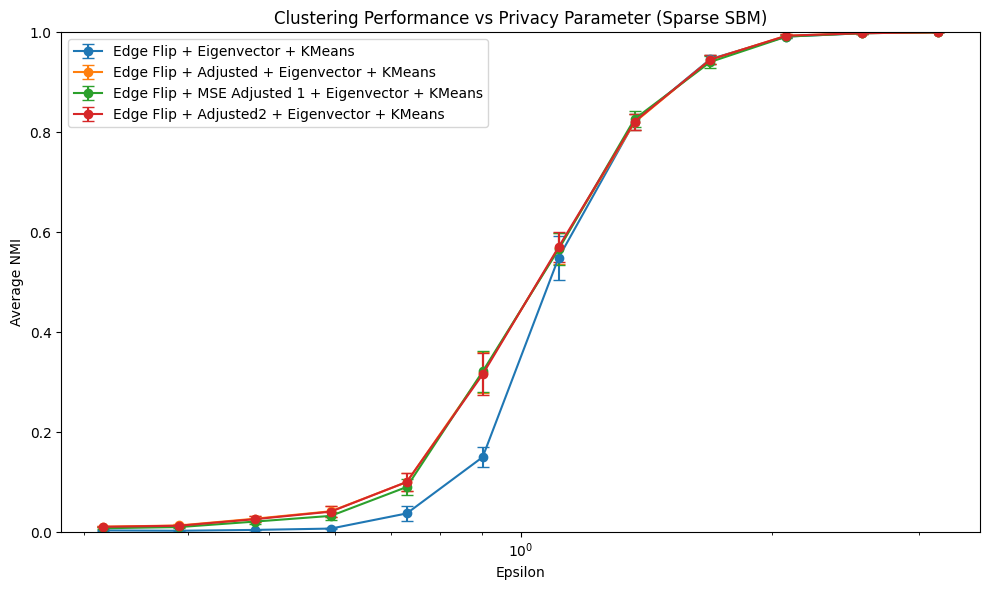

In [27]:
### Plotting NMI

# Compute mean and std for each method at each epsilon
method_means = {}
method_stds = {}
for method in results:
    means = []
    stds = []
    for j, eps in enumerate(epsilon_values):
        nmi_scores = [v for v in results[method][j] if v is not None]
        if len(nmi_scores) > 0:
            means.append(np.mean(nmi_scores))
            stds.append(np.std(nmi_scores, ddof=1)/np.sqrt(sample_size))
        else:
            means.append(np.nan)
            stds.append(np.nan)
    method_means[method] = means
    method_stds[method] = stds

# Plot
plt.figure(figsize=(10, 6))
for i, method in enumerate(results.keys()):
    means = method_means[method]
    stds = method_stds[method]
    plt.errorbar(
        [float(e) for e in epsilon_values], 
        means, 
        yerr=stds, 
        label=method, 
        marker='o', 
        capsize=4, 
        linestyle='-'
    )

plt.xscale('log')
plt.ylim(0,1)
plt.xlabel('Epsilon')
plt.ylabel('Average NMI')
plt.title('Clustering Performance vs Privacy Parameter (Sparse SBM)')
plt.legend()
plt.tight_layout()
plt.show()

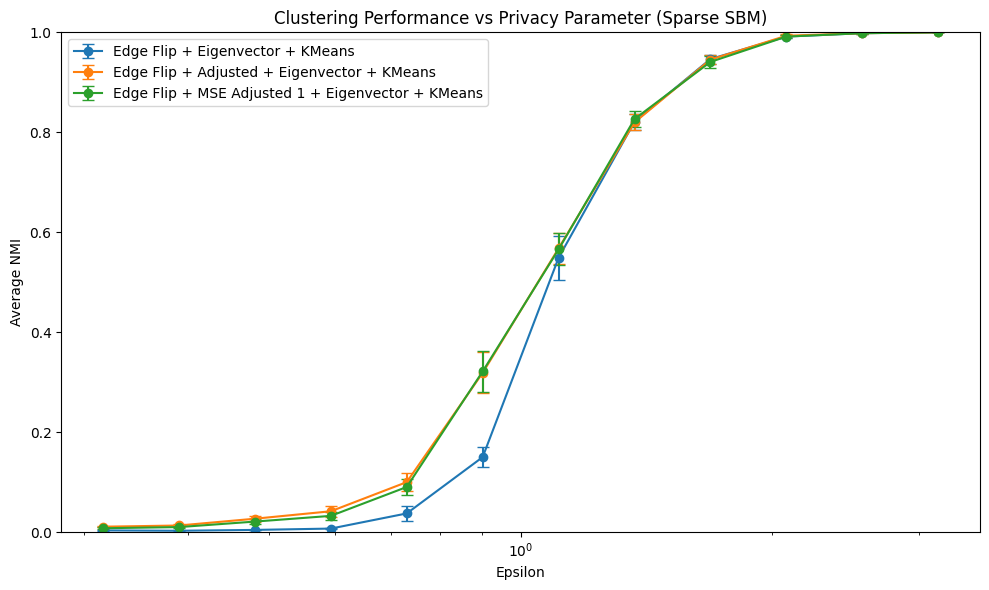

In [62]:
### Plotting NMI

# Compute mean and std for each method at each epsilon
method_means = {}
method_stds = {}
for method in results:
    means = []
    stds = []
    for j, eps in enumerate(epsilon_values):
        nmi_scores = [v for v in results[method][j] if v is not None]
        if len(nmi_scores) > 0:
            means.append(np.mean(nmi_scores))
            stds.append(np.std(nmi_scores, ddof=1)/np.sqrt(sample_size))
        else:
            means.append(np.nan)
            stds.append(np.nan)
    method_means[method] = means
    method_stds[method] = stds

# Plot
plt.figure(figsize=(10, 6))
for i, method in enumerate(results.keys()):
    means = method_means[method]
    stds = method_stds[method]
    plt.errorbar(
        [float(e) for e in epsilon_values], 
        means, 
        yerr=stds, 
        label=method, 
        marker='o', 
        capsize=4, 
        linestyle='-'
    )

plt.xscale('log')
plt.ylim(0,1)
plt.xlabel('Epsilon')
plt.ylabel('Average NMI')
plt.title('Clustering Performance vs Privacy Parameter (Sparse SBM)')
plt.legend()
plt.tight_layout()
plt.show()

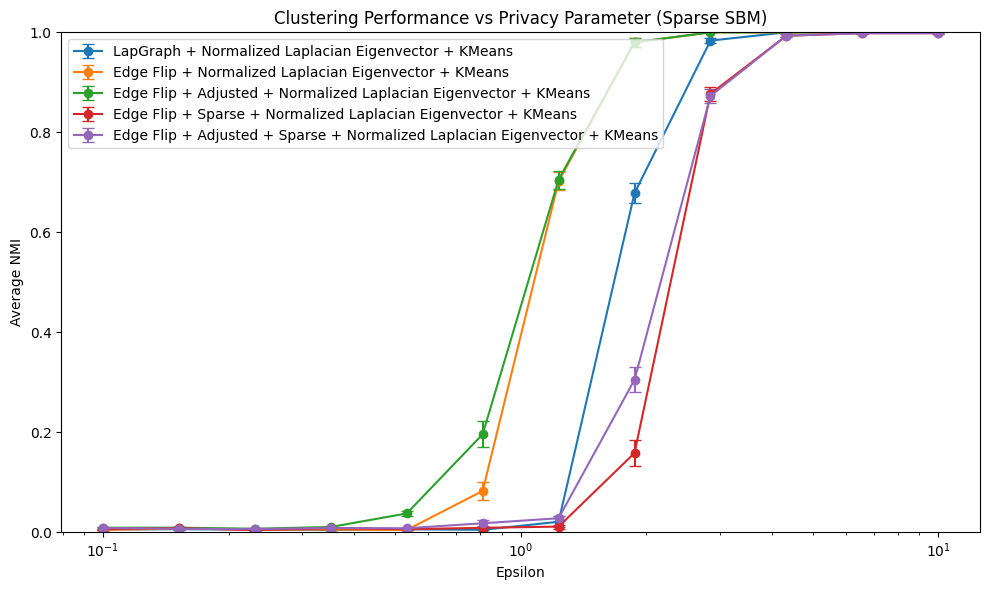

In [12]:
### Plotting NMI

# Compute mean and std for each method at each epsilon
method_means = {}
method_stds = {}
for method in results:
    means = []
    stds = []
    for j, eps in enumerate(epsilon_values):
        nmi_scores = [v for v in results[method][j] if v is not None]
        if len(nmi_scores) > 0:
            means.append(np.mean(nmi_scores))
            stds.append(np.std(nmi_scores, ddof=1)/np.sqrt(sample_size))
        else:
            means.append(np.nan)
            stds.append(np.nan)
    method_means[method] = means
    method_stds[method] = stds

# Plot
plt.figure(figsize=(10, 6))
for i, method in enumerate(results.keys()):
    means = method_means[method]
    stds = method_stds[method]
    plt.errorbar(
        [float(e) for e in epsilon_values], 
        means, 
        yerr=stds, 
        label=method, 
        marker='o', 
        capsize=4, 
        linestyle='-'
    )

plt.xscale('log')
plt.ylim(0,1)
plt.xlabel('Epsilon')
plt.ylabel('Average NMI')
plt.title('Clustering Performance vs Privacy Parameter (Sparse SBM)')
plt.legend()
plt.tight_layout()
plt.show()

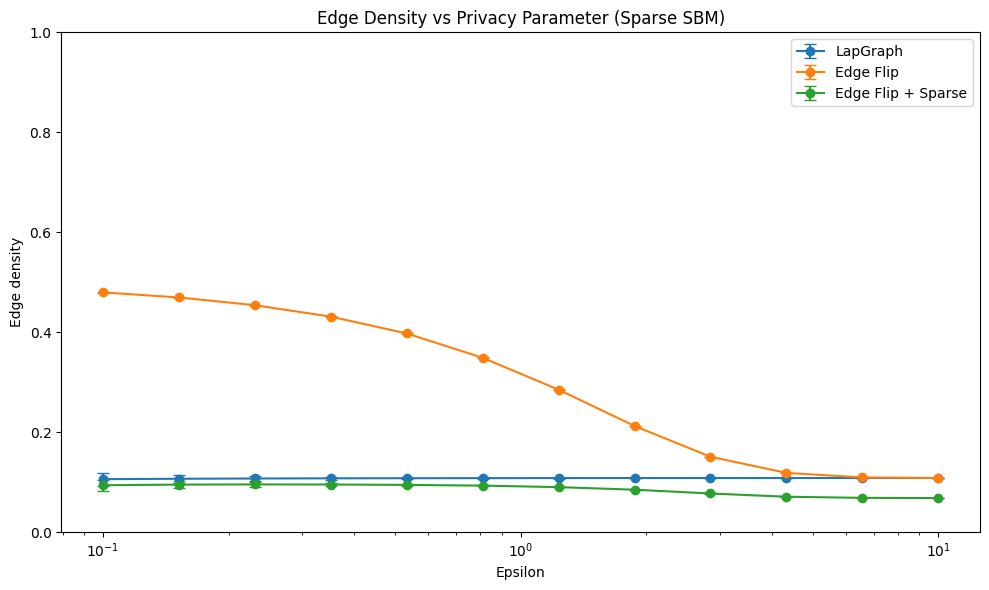

In [15]:
### Plotting edge density

# Compute mean and std for each method at each epsilon
method_means = {}
method_stds = {}
for method in edge_density:
    means = []
    stds = []
    for j, eps in enumerate(epsilon_values):
        density_scores = [v for v in edge_density[method][j] if v is not None]
        if len(density_scores) > 0:
            means.append(np.mean(density_scores))
            stds.append(np.std(density_scores, ddof=1)/np.sqrt(sample_size))
        else:
            means.append(np.nan)
            stds.append(np.nan)
    method_means[method] = means
    method_stds[method] = stds

# Plot
plt.figure(figsize=(10, 6))
for i, method in enumerate(edge_density.keys()):
    means = method_means[method]
    stds = method_stds[method]
    plt.errorbar(
        [float(e) for e in epsilon_values], 
        means, 
        yerr=stds, 
        label=method, 
        marker='o', 
        capsize=4, 
        linestyle='-'
    )

plt.xscale('log')
plt.ylim(0,1)
plt.xlabel('Epsilon')
plt.ylabel('Edge density')
plt.title('Edge Density vs Privacy Parameter (Sparse SBM)')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
epsilon_values
epsilon = 1.23284674
n_clusters = 3

In [32]:
sample_size = 5
for T in range(5000, 5001, 4000):
    score = []
    n_edges = []
    for r in range(sample_size):
        A_ef_sparse = edge_flip_sparsified_test(A, epsilon, T=2003000)
        A_ef_sparse_adjusted = A_ef_sparse/(np.exp(epsilon) - 1)/(np.exp(epsilon) + 1) - (1/(np.exp(epsilon) - 1)*(np.ones(n,n) - np.eye(n)))

        # A_ef_sparse = edge_flip(A, epsilon)
        eigvals, eigvecs = np.linalg.eigh(A_ef_sparse_adjusted)
        topk_indices = np.argsort(np.abs(eigvals))[::-1][:n_clusters]
        eigvecs = eigvecs[:, topk_indices]
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=seed)
        cluster_labels = kmeans.fit_predict(eigvecs)
        
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)

        score.append(nmi_score)
        n_edges.append(np.sum((A_ef_sparse>0)/2))

    print(f"T: {T}, nmi_score: {np.average(np.array(score))}, num edges: {np.average(np.array(n_edges))}")

T: 5000, nmi_score: 0.6723026173235143, num edges: 12876.6


In [18]:
np.sum(A)/2

4813.0

In [45]:
sample_size = 5
for T in range(2000, 20001, 4000):
    score = []
    n_edges = []
    for r in range(sample_size):
        A_ef_sparse = edge_flip_sparsified_test(A, epsilon, n_edge=T)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        cluster_labels = spectral_clustering.fit_predict(A_ef_sparse)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        
        score.append(nmi_score)
        n_edges.append(np.sum((A_ef_sparse>0)/2))

    print(f"T: {T}, nmi_score: {np.average(np.array(score))}, num edges: {np.average(np.array(n_edges))}")

T: 2000, nmi_score: 0.031642786068376574, num edges: 2035.8
T: 6000, nmi_score: 0.09594779969119965, num edges: 6069.4
T: 10000, nmi_score: 0.2867917361900774, num edges: 10041.6


KeyboardInterrupt: 

In [48]:
#save output
import os
import json


def convert_to_json_serializable(obj):
    # Recursively convert numpy types to native Python types
    if isinstance(obj, dict):
        return {k: convert_to_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_json_serializable(v) for v in obj]
    elif hasattr(obj, "tolist"):
        return obj.tolist()
    elif obj is None:
        return None
    else:
        return obj

os.makedirs("logs", exist_ok=True)
with open("logs/ours/sparse_sbm_with_spectral_sparse.json", "w") as f:
    json.dump(convert_to_json_serializable(results), f)

## Dense DC-SBM

In [15]:
sizes = [100, 100, 100]
n = np.sum(sizes)
p = 0.4
r = 0.05
a = 0.3
print(f"Intra prob: {p}")
print(f"Inter prob: {r}")
deepwalk_dimension=32
n_clusters = 3
sample_size = 10

probs = [
    [p, r, r],
    [r, p, r],
    [r, r, p],
]

# Define epsilon values to test
epsilon_values = np.logspace(-1, 3, num=12) 

# Initialize results storage
results = {
    'Spectral Clustering - no Privacy': [[] for _ in range(len(epsilon_values))],
    'LapGraph + Normalized Laplacian Eigenvector + KMeans': [[] for _ in range(len(epsilon_values))],
    'Edge Flip + Normalized Laplacian Eigenvector + KMeans': [[] for _ in range(len(epsilon_values))],
    'LapGraph + DeepWalk + KMeans': [[] for _ in range(len(epsilon_values))],
    'Edge Flip + DeepWalk + Kmeans': [[] for _ in range(len(epsilon_values))]
}

# Test each epsilon value
for idx, epsilon in enumerate(epsilon_values):
    print(f"Testing epsilon = {epsilon}")

    for run in range(sample_size):
        seed = run
        np.random.seed(seed)

        #### Generate the SBM graph
        G, true_labels = degree_corrected_sbm(sizes, probs, a=a, seed=None)

        # G, true_labels = degree_corrected_sbm(sizes, probs, a = a, seed=seed)
        A = nx.to_numpy_array(G)

        #### Evaluate

        # Original matrix (no perturbation)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        cluster_labels = spectral_clustering.fit_predict(A)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Spectral Clustering - no Privacy'][idx].append(nmi_score)

        # LapGraph + Normalized Laplacian Eigenvector + KMeans
        A_lg = lapgraph(A, epsilon)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        cluster_labels = spectral_clustering.fit_predict(A_lg)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['LapGraph + Normalized Laplacian Eigenvector + KMeans'][idx].append(nmi_score)
        
        # Edge Flip + Normalized Laplacian Eigenvector + KMeans 
        A_ef = edge_flip(A, epsilon)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        cluster_labels = spectral_clustering.fit_predict(A_ef)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Edge Flip + Normalized Laplacian Eigenvector + KMeans'][idx].append(nmi_score)

        # LapGraph + DeepWalk + KMeans
        G_test = nx.from_numpy_array(A_lg)
        X = deepwalk_get_embeddings(G_test, deepwalk_dimension, seed=seed)
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=seed)
        cluster_labels = kmeans.fit_predict(X)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['LapGraph + DeepWalk + KMeans'][idx].append(nmi_score)

        # Edge Flip + DeepWalk + Kmeans
        G_test = nx.from_numpy_array(A_ef)
        X = deepwalk_get_embeddings(G_test, deepwalk_dimension, seed=seed)
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=seed)
        cluster_labels = kmeans.fit_predict(X)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Edge Flip + DeepWalk + Kmeans'][idx].append(nmi_score)

Intra prob: 0.4
Inter prob: 0.05
Testing epsilon = 0.1
Theta: [1.0420708060904833, 0.7010970216903731, 0.8457422156250021, 1.1612810193989318, 1.0679472171360591, 0.84537718956767, 0.8385798239799647, 0.6388970216729919, 0.6268624325469567, 0.7037073450831604, 0.6370686123887868, 0.9646260963393112, 0.7913171508853156, 0.6314764737217744, 0.7120235277849238, 0.684476301442134, 0.9745774878879689, 0.6523472855400176, 0.6793246450112926, 0.8145816544239985, 1.239305173557087, 0.7644623684586576, 0.8171667693134439, 0.7865989747001778, 1.1684963755954691, 0.9646491382482585, 0.6124973489239289, 0.6478536821050258, 0.9842525231881818, 0.9683974120736387, 0.6397945760227963, 0.6955983494991107, 0.8230041565060955, 1.096256836654549, 0.6880357569301054, 0.6401449618745623, 0.9086303897804975, 0.9016526817946702, 0.6978894239505555, 0.6766334072424012, 0.8631959608653406, 0.9560622038933111, 1.0276252672548205, 1.0887515684065148, 0.7284707650364808, 0.7105762950013639, 0.914256559611049, 0.7

/tmp/ipykernel_12377/3100451036.py:8: RuntimeWarning: overflow encountered in exp
  x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon)))


Theta: [1.0071440605143778, 0.7539968230110863, 0.7331006576644312, 0.86929987513761, 0.8174096269297371, 1.176442393818638, 1.0372606606526873, 0.7913594448223431, 0.6808174936128419, 0.6634003134679198, 0.966584703859811, 1.1160928969729809, 0.6816620206019441, 0.6970713082656712, 0.8845000801824268, 0.8760305364270751, 0.6441647714861762, 0.8205223240789103, 0.6116111562774655, 0.7467615230275229, 0.8762125139017978, 0.8872386470584708, 0.8264553997467663, 0.7266813043240343, 0.8262717069146703, 0.7719896843921505, 0.6317802759782294, 0.8350000781633344, 0.6680297395050714, 0.7336465862831139, 0.7739729075298947, 0.7002461013125616, 0.7728508946284671, 0.8123591299732473, 0.768869252307772, 0.6042238693282926, 0.8803853067573868, 0.6596616440528404, 1.016008263876035, 0.7865687597429012, 0.6490166076889712, 0.8229649606197764, 0.7878472930362768, 1.024171369855504, 0.6137596582925746, 0.7603066312409057, 0.6487865907654338, 1.126121503718278, 0.6310974577189747, 0.7553584970254221, 

/tmp/ipykernel_12377/3100451036.py:8: RuntimeWarning: overflow encountered in exp
  x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon)))


Theta: [0.705247181449935, 0.6151244264051496, 1.135106743515681, 1.0111254216998145, 1.049416615897283, 0.8114945610126183, 0.726778073888078, 0.9123797412503754, 0.8655457743141521, 0.8283096233302798, 0.7389212307351734, 1.1741097228023067, 0.6114425678481683, 0.8805390808769467, 0.7358222997437647, 0.7500976445501841, 0.6058403437288553, 0.89480802447364, 0.7880254569220329, 0.6033140323418986, 0.8205846929086529, 0.6401662621947233, 0.6652003325988913, 0.8482524817909729, 0.6857632111058665, 0.6601037273117176, 0.7604714727196427, 0.8979607911948884, 0.9563620264245991, 0.6394315185178046, 0.6683219596525707, 1.1588994168202185, 1.2097496137288284, 0.6292393458027297, 0.6936688537643758, 0.9409661852667164, 0.7265220212938956, 0.8121111455560328, 0.6010601599664664, 0.7366458626358245, 0.6794347688469196, 0.7938106541159202, 1.0680803832395083, 1.0338538860936843, 0.9679772222419205, 0.6849770542295293, 0.7538929144919968, 0.6130503675656145, 0.8083415418522621, 0.6229852742006503

...

/tmp/ipykernel_12377/3100451036.py:8: RuntimeWarning: overflow encountered in exp
  x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon)))


Theta: [0.6238588987535223, 0.8738784029165949, 1.087800296854204, 0.9476451026578021, 1.1751806131491083, 1.2035162954339527, 1.0330167617435473, 1.1521967907376012, 0.7997646294356675, 0.8451629936988025, 0.8969145064318211, 1.0801486222324372, 0.881889419736352, 0.7670665869945936, 0.6956473621907071, 0.7989615374726515, 0.8159447468936607, 0.6587549684699636, 0.6174729766247653, 0.6532167782816063, 0.9377748621270798, 0.7527959189378481, 0.6446197730097254, 0.707070574856498, 1.0125552458045077, 0.7219429570898899, 0.734924782102508, 0.8925928411919966, 0.6414784967848375, 0.7692662013669547, 0.9616887525194184, 0.6564278723315233, 0.608873798020104, 0.6465401166060933, 0.6167899020650163, 0.7364498345952992, 0.7196873240698052, 0.8922055126294366, 0.726285067241424, 0.7031979593754414, 0.8346448088909324, 0.6221852581026792, 0.6369804741005543, 0.6199450799324819, 0.6399689937026978, 0.7387702336751487, 1.0265652085162538, 0.8525811452347101, 1.3847876615037258, 0.8859410946720394

/tmp/ipykernel_12377/3100451036.py:8: RuntimeWarning: overflow encountered in exp
  x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon)))


Theta: [0.60133485827662, 0.673443736911117, 0.880074295364671, 0.6042784087850159, 0.6956480856505469, 0.7213415603177933, 0.9803905142974854, 0.723775714904004, 0.6612278642242355, 0.7630445846539682, 0.7600304896602752, 1.0360870459198614, 0.6752282740264182, 0.7779336350615393, 1.0567616603781265, 0.7087499769732906, 0.986740125970589, 0.8262380124527395, 0.6353389721930687, 0.9254524726185798, 0.7698755114566138, 0.6090472488402421, 0.8305941936729377, 0.6961850862086276, 0.7301495914080443, 0.6898675841850932, 0.6532519699053725, 0.6831604885906786, 0.7256139112184408, 1.1240019129836842, 0.6217046547539502, 1.2148533826735695, 1.2690852206415524, 0.8293775397452539, 0.657886308909712, 0.668386563838822, 0.8836730337927383, 0.8616570814645577, 0.9270103303687027, 0.9484079026890271, 0.7651708639798922, 0.6151220435679254, 0.7260333745002205, 0.7101625648387659, 0.6950109813213023, 0.8318231153113871, 1.0803702801374915, 0.6386334300494707, 0.7607401585729381, 0.8072503022241024, 

/tmp/ipykernel_12377/3100451036.py:8: RuntimeWarning: overflow encountered in exp
  x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon)))


In [21]:
results = {"Spectral Clustering - no Privacy": [[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]], "LapGraph + Normalized Laplacian Eigenvector + KMeans": [[0.015579314399644273, 0.007545825822990989, 0.0023047105977273678, 0.00820780490430326, 0.006722256762355865, 0.005113692699507994, 0.010422620630305017, 0.004931814630070541, 0.006608740121324156, 0.016738221373064414], [0.01572441151938684, 0.003117485735866835, 0.005293249793792609, 0.007173854397813237, 0.004932945774020017, 0.00564723984496425, 0.009295953488241498, 0.005392664778632298, 0.004119055521128483, 0.009103620294827414], [0.024364337289183163, 0.016279243086346158, 0.0050479912922988925, 0.008298647240009305, 0.0066034425145193, 0.0024584368032989005, 0.02152443172853714, 0.008903767243451618, 0.009040958141417766, 0.028158182802587518], [0.037426704067305507, 0.023813485361390736, 0.05327975752070957, 0.054010227088400156, 0.02062848831214519, 0.020253281235567636, 0.09903022471824065, 0.04879313456330284, 0.07343859452009524, 0.08024291021577025], [0.9362675105575323, 0.9589753057921956, 1.0, 0.9829929733076641, 0.9829929733076642, 0.9192439186236645, 0.9829929733076642, 0.9829929733076641, 0.9362834892881853, 0.9192748815579214], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]], "Edge Flip + Normalized Laplacian Eigenvector + KMeans": [[0.003945741142445526, 0.0027102424009519508, 0.014707809368098538, 0.012117961313746333, 0.0033920327741066487, 0.009565017723614124, 0.0026102436273372537, 0.016541963955684465, 0.006737536743270821, 0.004172282983990852], [0.015304827208718244, 0.001215345750547261, 0.008945350545440059, 0.01132813697105136, 0.01587925662429131, 0.018847084483590314, 0.006991043221566483, 0.010421324583644, 0.006204471247765854, 0.010922642976417145], [0.033400759257039996, 0.00592179414990067, 0.011259071027306795, 0.006063601256870785, 0.027897429353373943, 0.035968649814846564, 0.06755981866946174, 0.03295752644820208, 0.03012661832361095, 0.013773104373282863], [0.6209199354872327, 0.6256550439415075, 0.6065390366161715, 0.6927267958334357, 0.6876141594227904, 0.5424415167696804, 0.7235824471986133, 0.5243385443149612, 0.5464411439806398, 0.6062750530337208], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9829929733076641], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]], "LapGraph + DeepWalk + KMeans": [[0.009736900122824313, 0.0038971720172932154, 0.008338144686146286, 0.0019985607060982787, 0.001683552573029347, 0.004496302334275495, 0.003250659070908751, 0.006874208351493828, 0.008814661770092113, 0.00647261655477971], [0.004687601222914562, 0.0016272779471220508, 0.0021874309231207805, 0.0036072971462910233, 0.001432719100251007, 0.0039444876600257415, 0.006785515371174771, 0.004976345531489924, 0.0012528951007139213, 0.01757457649557369], [0.0007456616487632101, 0.0010948065563735894, 0.014149148583753582, 0.014725816461039374, 0.00585167210433169, 0.004328285791653762, 0.005142766652334919, 0.01054264235231552, 0.015511306075439215, 0.008889344567757737], [0.03664804784729436, 0.022101995821614345, 0.04791536351343381, 0.0388047088412487, 0.022833939384620562, 0.030546312226954614, 0.06757136179811644, 0.05385283370296831, 0.04397149348751904, 0.023236894181009483], [0.9362834892881853, 0.925069034828595, 0.9829929733076641, 0.9660011177521189, 0.953214250859651, 0.9023319040145938, 0.9829929733076642, 0.9660011177521189, 0.9065857160471523, 0.9490092621965739], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]], "Edge Flip + DeepWalk + Kmeans": [[0.006896361704858254, 0.00886306181844388, 0.015322259962108174, 0.0021660453292460338, 0.021170028639488928, 0.010701025122551758, 0.0032855943050397224, 0.009263837409229552, 0.000586368466053866, 0.007546943028580944], [0.002599212470215254, 0.0029194507297519265, 0.006138477436660258, 0.002756830114741909, 0.0028436970472742085, 0.0022277613116177793, 0.004661589154164464, 0.004665366944149345, 0.0013485060656167338, 0.009423206540394052], [0.0052874099915523635, 0.005069361350968624, 0.010825072501997301, 0.0014149935604364553, 0.012231474763463824, 0.013630834729258247, 0.002572562700840345, 0.009149158815774756, 0.0043201627866656656, 0.014008882079733003], [0.19664667192169713, 0.36659630647105973, 0.12628925523250428, 0.3596003098111767, 0.3599563396794328, 0.14554822880540755, 0.42394816817284814, 0.18441269610203606, 0.17021016225722105, 0.36781431640505347], [0.9829929733076641, 1.0, 1.0, 1.0, 1.0, 0.9829929733076641, 0.9829929733076641, 1.0, 0.9660011177521189, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]]}

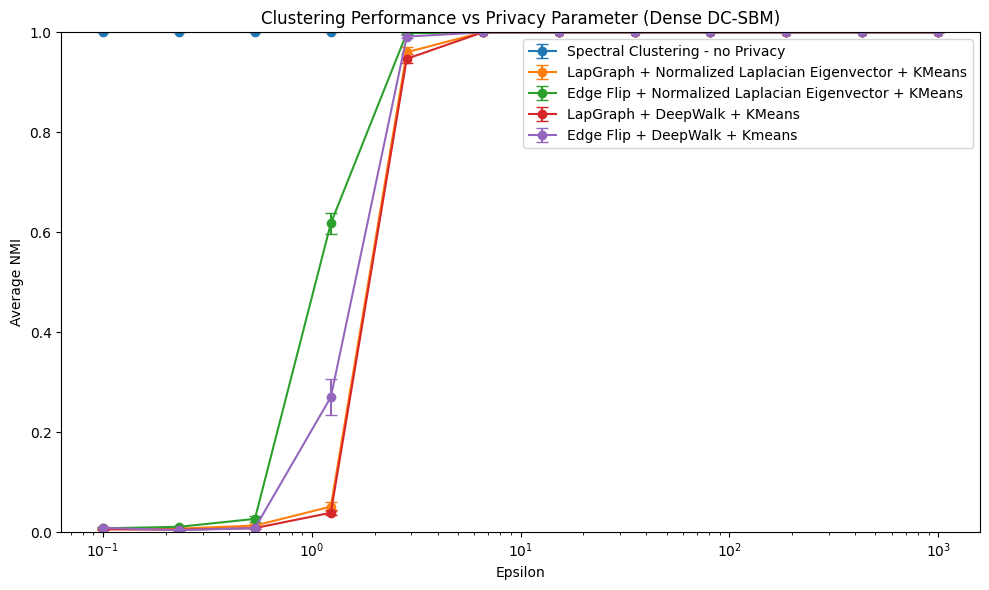

In [22]:
### Plotting

# Compute mean and std for each method at each epsilon
method_means = {}
method_stds = {}
for method in results:
    means = []
    stds = []
    for j, eps in enumerate(epsilon_values):
        nmi_scores = [v for v in results[method][j] if v is not None]
        if len(nmi_scores) > 0:
            means.append(np.mean(nmi_scores))
            stds.append(np.std(nmi_scores, ddof=1)/np.sqrt(sample_size))
        else:
            means.append(np.nan)
            stds.append(np.nan)
    method_means[method] = means
    method_stds[method] = stds

# Plot
plt.figure(figsize=(10, 6))
for i, method in enumerate(results.keys()):
    means = method_means[method]
    stds = method_stds[method]
    plt.errorbar(
        [float(e) for e in epsilon_values], 
        means, 
        yerr=stds, 
        label=method, 
        marker='o', 
        capsize=4, 
        linestyle='-'
    )

plt.xscale('log')
plt.ylim(0,1)
plt.xlabel('Epsilon')
plt.ylabel('Average NMI')
plt.title('Clustering Performance vs Privacy Parameter (Dense DC-SBM)')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
epsilon = 1
# LapGraph + Normalized Laplacian Eigenvector + KMeans
A_lg = lapgraph(A, epsilon)

# Edge Flip + Normalized Laplacian Eigenvector + KMeans 
A_ef = edge_flip(A, epsilon)


In [27]:
np.sum(A)/2

5126.0

In [25]:
np.sum(A_lg)/2

4738.0

In [26]:
np.sum(A_ef)/2

14374.0

In [17]:
#save output
import os
import json


def convert_to_json_serializable(obj):
    # Recursively convert numpy types to native Python types
    if isinstance(obj, dict):
        return {k: convert_to_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_json_serializable(v) for v in obj]
    elif hasattr(obj, "tolist"):
        return obj.tolist()
    elif obj is None:
        return None
    else:
        return obj

os.makedirs("logs", exist_ok=True)
with open("logs/ours/dense_dsbm.json", "w") as f:
    json.dump(convert_to_json_serializable(results), f)

## Sparse DC-SBM

In [18]:
sizes = [100, 100, 100]
n = np.sum(sizes)
p = 2*n**(-0.25)
r = 0.1*n**(-0.25)
a = 0.3
print(f"Intra prob: {p}")
print(f"Inter prob: {r}")
deepwalk_dimension=32
n_clusters = 3
sample_size = 10

probs = [
    [p, r, r],
    [r, p, r],
    [r, r, p],
]

# Define epsilon values to test
epsilon_values = np.logspace(-1, 3, num=12) 

# Initialize results storage
results = {
    'Spectral Clustering - no Privacy': [[] for _ in range(len(epsilon_values))],
    'LapGraph + Normalized Laplacian Eigenvector + KMeans': [[] for _ in range(len(epsilon_values))],
    'Edge Flip + Normalized Laplacian Eigenvector + KMeans': [[] for _ in range(len(epsilon_values))],
    'LapGraph + DeepWalk + KMeans': [[] for _ in range(len(epsilon_values))],
    'Edge Flip + DeepWalk + Kmeans': [[] for _ in range(len(epsilon_values))]
}

# Test each epsilon value
for idx, epsilon in enumerate(epsilon_values):
    print(f"Testing epsilon = {epsilon}")

    for run in range(sample_size):
        seed = run
        np.random.seed(seed)

        #### Generate the SBM graph
        G, true_labels = degree_corrected_sbm(sizes, probs, a=a, seed=None)

        # G, true_labels = degree_corrected_sbm(sizes, probs, a = a, seed=seed)
        A = nx.to_numpy_array(G)

        #### Evaluate

        # Original matrix (no perturbation)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        cluster_labels = spectral_clustering.fit_predict(A)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Spectral Clustering - no Privacy'][idx].append(nmi_score)

        # LapGraph + Normalized Laplacian Eigenvector + KMeans
        A_lg = lapgraph(A, epsilon)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        cluster_labels = spectral_clustering.fit_predict(A_lg)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['LapGraph + Normalized Laplacian Eigenvector + KMeans'][idx].append(nmi_score)
        
        # Edge Flip + Normalized Laplacian Eigenvector + KMeans 
        A_ef = edge_flip(A, epsilon)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        cluster_labels = spectral_clustering.fit_predict(A_ef)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Edge Flip + Normalized Laplacian Eigenvector + KMeans'][idx].append(nmi_score)

        # LapGraph + DeepWalk + KMeans
        G_test = nx.from_numpy_array(A_lg)
        X = deepwalk_get_embeddings(G_test, deepwalk_dimension, seed=seed)
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=seed)
        cluster_labels = kmeans.fit_predict(X)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['LapGraph + DeepWalk + KMeans'][idx].append(nmi_score)

        # Edge Flip + DeepWalk + Kmeans
        G_test = nx.from_numpy_array(A_ef)
        X = deepwalk_get_embeddings(G_test, deepwalk_dimension, seed=seed)
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=seed)
        cluster_labels = kmeans.fit_predict(X)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Edge Flip + DeepWalk + Kmeans'][idx].append(nmi_score)

Intra prob: 0.48056228282695085
Inter prob: 0.024028114141347545
Testing epsilon = 0.1
Theta: [1.0420708060904833, 0.7010970216903731, 0.8457422156250021, 1.1612810193989318, 1.0679472171360591, 0.84537718956767, 0.8385798239799647, 0.6388970216729919, 0.6268624325469567, 0.7037073450831604, 0.6370686123887868, 0.9646260963393112, 0.7913171508853156, 0.6314764737217744, 0.7120235277849238, 0.684476301442134, 0.9745774878879689, 0.6523472855400176, 0.6793246450112926, 0.8145816544239985, 1.239305173557087, 0.7644623684586576, 0.8171667693134439, 0.7865989747001778, 1.1684963755954691, 0.9646491382482585, 0.6124973489239289, 0.6478536821050258, 0.9842525231881818, 0.9683974120736387, 0.6397945760227963, 0.6955983494991107, 0.8230041565060955, 1.096256836654549, 0.6880357569301054, 0.6401449618745623, 0.9086303897804975, 0.9016526817946702, 0.6978894239505555, 0.6766334072424012, 0.8631959608653406, 0.9560622038933111, 1.0276252672548205, 1.0887515684065148, 0.7284707650364808, 0.71057629

/tmp/ipykernel_12377/3100451036.py:8: RuntimeWarning: overflow encountered in exp
  x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon)))


Theta: [1.0071440605143778, 0.7539968230110863, 0.7331006576644312, 0.86929987513761, 0.8174096269297371, 1.176442393818638, 1.0372606606526873, 0.7913594448223431, 0.6808174936128419, 0.6634003134679198, 0.966584703859811, 1.1160928969729809, 0.6816620206019441, 0.6970713082656712, 0.8845000801824268, 0.8760305364270751, 0.6441647714861762, 0.8205223240789103, 0.6116111562774655, 0.7467615230275229, 0.8762125139017978, 0.8872386470584708, 0.8264553997467663, 0.7266813043240343, 0.8262717069146703, 0.7719896843921505, 0.6317802759782294, 0.8350000781633344, 0.6680297395050714, 0.7336465862831139, 0.7739729075298947, 0.7002461013125616, 0.7728508946284671, 0.8123591299732473, 0.768869252307772, 0.6042238693282926, 0.8803853067573868, 0.6596616440528404, 1.016008263876035, 0.7865687597429012, 0.6490166076889712, 0.8229649606197764, 0.7878472930362768, 1.024171369855504, 0.6137596582925746, 0.7603066312409057, 0.6487865907654338, 1.126121503718278, 0.6310974577189747, 0.7553584970254221, 

/tmp/ipykernel_12377/3100451036.py:8: RuntimeWarning: overflow encountered in exp
  x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon)))


Theta: [0.705247181449935, 0.6151244264051496, 1.135106743515681, 1.0111254216998145, 1.049416615897283, 0.8114945610126183, 0.726778073888078, 0.9123797412503754, 0.8655457743141521, 0.8283096233302798, 0.7389212307351734, 1.1741097228023067, 0.6114425678481683, 0.8805390808769467, 0.7358222997437647, 0.7500976445501841, 0.6058403437288553, 0.89480802447364, 0.7880254569220329, 0.6033140323418986, 0.8205846929086529, 0.6401662621947233, 0.6652003325988913, 0.8482524817909729, 0.6857632111058665, 0.6601037273117176, 0.7604714727196427, 0.8979607911948884, 0.9563620264245991, 0.6394315185178046, 0.6683219596525707, 1.1588994168202185, 1.2097496137288284, 0.6292393458027297, 0.6936688537643758, 0.9409661852667164, 0.7265220212938956, 0.8121111455560328, 0.6010601599664664, 0.7366458626358245, 0.6794347688469196, 0.7938106541159202, 1.0680803832395083, 1.0338538860936843, 0.9679772222419205, 0.6849770542295293, 0.7538929144919968, 0.6130503675656145, 0.8083415418522621, 0.6229852742006503

...

/tmp/ipykernel_12377/3100451036.py:8: RuntimeWarning: overflow encountered in exp
  x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon)))


Theta: [0.6238588987535223, 0.8738784029165949, 1.087800296854204, 0.9476451026578021, 1.1751806131491083, 1.2035162954339527, 1.0330167617435473, 1.1521967907376012, 0.7997646294356675, 0.8451629936988025, 0.8969145064318211, 1.0801486222324372, 0.881889419736352, 0.7670665869945936, 0.6956473621907071, 0.7989615374726515, 0.8159447468936607, 0.6587549684699636, 0.6174729766247653, 0.6532167782816063, 0.9377748621270798, 0.7527959189378481, 0.6446197730097254, 0.707070574856498, 1.0125552458045077, 0.7219429570898899, 0.734924782102508, 0.8925928411919966, 0.6414784967848375, 0.7692662013669547, 0.9616887525194184, 0.6564278723315233, 0.608873798020104, 0.6465401166060933, 0.6167899020650163, 0.7364498345952992, 0.7196873240698052, 0.8922055126294366, 0.726285067241424, 0.7031979593754414, 0.8346448088909324, 0.6221852581026792, 0.6369804741005543, 0.6199450799324819, 0.6399689937026978, 0.7387702336751487, 1.0265652085162538, 0.8525811452347101, 1.3847876615037258, 0.8859410946720394

/tmp/ipykernel_12377/3100451036.py:8: RuntimeWarning: overflow encountered in exp
  x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon)))


Theta: [0.60133485827662, 0.673443736911117, 0.880074295364671, 0.6042784087850159, 0.6956480856505469, 0.7213415603177933, 0.9803905142974854, 0.723775714904004, 0.6612278642242355, 0.7630445846539682, 0.7600304896602752, 1.0360870459198614, 0.6752282740264182, 0.7779336350615393, 1.0567616603781265, 0.7087499769732906, 0.986740125970589, 0.8262380124527395, 0.6353389721930687, 0.9254524726185798, 0.7698755114566138, 0.6090472488402421, 0.8305941936729377, 0.6961850862086276, 0.7301495914080443, 0.6898675841850932, 0.6532519699053725, 0.6831604885906786, 0.7256139112184408, 1.1240019129836842, 0.6217046547539502, 1.2148533826735695, 1.2690852206415524, 0.8293775397452539, 0.657886308909712, 0.668386563838822, 0.8836730337927383, 0.8616570814645577, 0.9270103303687027, 0.9484079026890271, 0.7651708639798922, 0.6151220435679254, 0.7260333745002205, 0.7101625648387659, 0.6950109813213023, 0.8318231153113871, 1.0803702801374915, 0.6386334300494707, 0.7607401585729381, 0.8072503022241024, 

/tmp/ipykernel_12377/3100451036.py:8: RuntimeWarning: overflow encountered in exp
  x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon)))


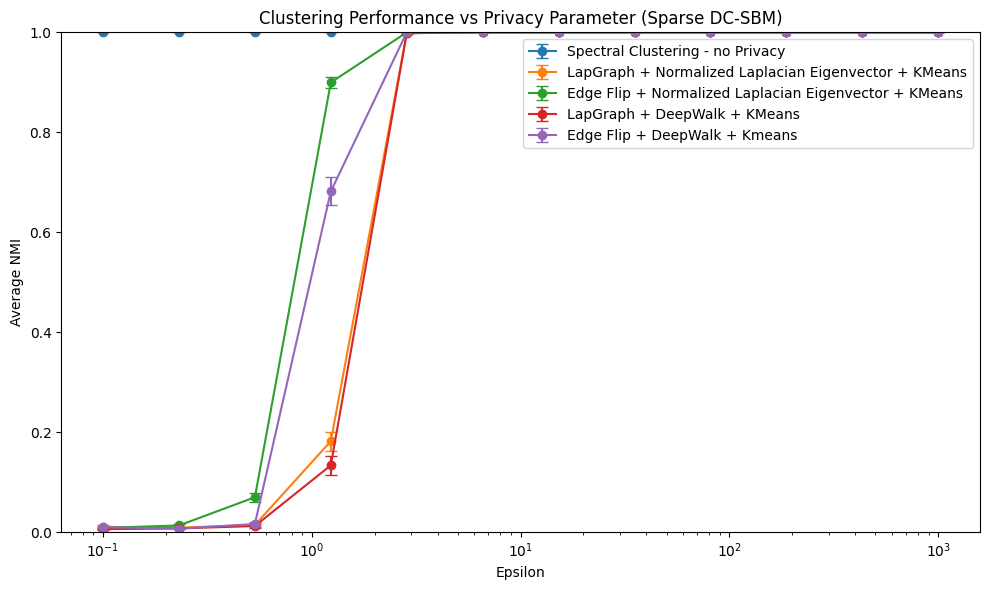

In [19]:
### Plotting

# Compute mean and std for each method at each epsilon
method_means = {}
method_stds = {}
for method in results:
    means = []
    stds = []
    for j, eps in enumerate(epsilon_values):
        nmi_scores = [v for v in results[method][j] if v is not None]
        if len(nmi_scores) > 0:
            means.append(np.mean(nmi_scores))
            stds.append(np.std(nmi_scores, ddof=1)/np.sqrt(sample_size))
        else:
            means.append(np.nan)
            stds.append(np.nan)
    method_means[method] = means
    method_stds[method] = stds

# Plot
plt.figure(figsize=(10, 6))
for i, method in enumerate(results.keys()):
    means = method_means[method]
    stds = method_stds[method]
    plt.errorbar(
        [float(e) for e in epsilon_values], 
        means, 
        yerr=stds, 
        label=method, 
        marker='o', 
        capsize=4, 
        linestyle='-'
    )

plt.xscale('log')
plt.ylim(0,1)
plt.xlabel('Epsilon')
plt.ylabel('Average NMI')
plt.title('Clustering Performance vs Privacy Parameter (Sparse DC-SBM)')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
#save output
import os
import json


def convert_to_json_serializable(obj):
    # Recursively convert numpy types to native Python types
    if isinstance(obj, dict):
        return {k: convert_to_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_json_serializable(v) for v in obj]
    elif hasattr(obj, "tolist"):
        return obj.tolist()
    elif obj is None:
        return None
    else:
        return obj

os.makedirs("logs", exist_ok=True)
with open("logs/ours/sparse_dsbm.json", "w") as f:
    json.dump(convert_to_json_serializable(results), f)